# Import librairies

In [1]:
import pandas as pd, numpy as np, seaborn as sns, warnings, os
from datetime import datetime as dt
from matplotlib import pyplot as plt

import matplotlib.font_manager as fm
import plotly.express as px
import plotly.graph_objs as go

font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
sns.set(font_scale=3)

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Outils

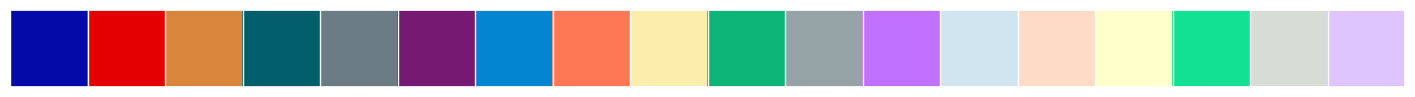

In [3]:
palette = [ "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", 
            "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe", 
            "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#dfc5fe", 
          ]
sns.palplot(sns.color_palette(palette))

In [4]:
repertoireRacine  = '.'
nomProjet         = 'ConsolidationDonneesMeteoJour'

repertoireProjet  = os.path.join(repertoireRacine, nomProjet)
repertoireDonnees = os.path.join(repertoireProjet, 'repertoire.donnees')
repertoireImages  = os.path.join(repertoireProjet, 'repertoire.images')


def controleExistenceRepertoire( repertoire, create_if_needed=True):
    """Voir si le répertoire existe. S'il n'existe pas il est créé."""
    path_exists = os.path.exists(repertoire)
    if path_exists:
        if not os.path.isdir(repertoire):
            raise Exception("Trouvé le nom  "+repertoire +" mais c'est un fichier, pas un répertoire")
            # return False
        return True
    if create_if_needed:
        os.makedirs(repertoire)

def sauvegarderImage( fichier):
    """Enregistrez la figure. Appelez la méthode juste avant plt.show ()."""
    controleExistenceRepertoire(repertoireImages)
    plt.savefig(os.path.join(repertoireImages,
                             fichier+f"--{dt.now().strftime('%Y_%m_%d_%H.%M.%S')}.png"), 
                             dpi=600, 
                             bbox_inches='tight')

def sauvegarderImageSNS( sns_plot, fichier):
    """Enregistrez la figure. Appelez la méthode juste avant plt.show ()."""
    controleExistenceRepertoire(repertoireImages)
    fig = sns_plot.get_figure()
    fig.savefig(os.path.join(repertoireImages,fichier+'.png'))
    
controleExistenceRepertoire(repertoireProjet);
controleExistenceRepertoire(repertoireDonnees);
controleExistenceRepertoire(repertoireImages);

In [5]:
donnees = pd.read_parquet("donnees/donnees_meteo.gzip")
donnees.set_index(['Nom', 'Latitude', 'Longitude', 'Altitude', 'Zone'],inplace=True)

In [6]:
donnees[['VitesseVent','Temperature','Humidite','Pression','Visibilite','Precipitation']].head()

VitesseVent  Temperature  \
Nom       Latitude Longitude Altitude Zone                             
Abbeville 50.136   1.834     69       NO            2.0         2.89   
                                      NO            3.0         2.70   
                                      NO            3.0         2.89   
                                      NO            4.1         3.60   
                                      NO            5.1         4.39   

                                            Humidite  Pression  Visibilite  \
Nom       Latitude Longitude Altitude Zone                                   
Abbeville 50.136   1.834     69       NO        99.0     990.9         NaN   
                                      NO        99.0     990.7         NaN   
                                      NO        99.0     990.9         0.1   
                                      NO        99.0     991.1         0.8   
                                      NO        99.0     990.4         1.6   

                                            Precipitation  
Nom       Latitude Longitude Altitude Zone                 
Abbeville 50.136   1.834     69       NO              0.0  
                                      NO              0.2  
                                      NO              0.0  
                                      NO              0.0  
                                      NO              0.0

# Moyenne journalière  par ville 

In [7]:
donneesJ = donnees.reset_index().pivot_table(index=['Nom', 'Latitude', 'Longitude', 'Altitude', 'Zone'],
                                 columns='JourA',
                                 values=['Temperature','Humidite','Pression'],  
                                 aggfunc = 'mean',
                                 sort = False)

donneesJ.columns=[f'{column[0]}{column[1]:03d}' for column in donneesJ.columns]
donneesJ.to_parquet(os.path.join(repertoireDonnees,'donneesJ.gzip'),compression='gzip', engine='pyarrow') 
donneesJ.head()

,,,,,Temperature001,Temperature002,Temperature003,Temperature004,Temperature005,Temperature006,Temperature007,Temperature008,Temperature009,Temperature010,...,Pression357,Pression358,Pression359,Pression360,Pression361,Pression362,Pression363,Pression364,Pression365,Pression366
Nom,Latitude,Longitude,Altitude,Zone,,,,,,,,,,,,,,,,,,,,,
Abbeville,50.136000,1.834000,69,NO,4.683491,5.295043,4.985109,5.023664,4.936724,4.831638,5.358621,5.318319,5.057155,4.239267,...,1009.416071,1007.329018,1006.813393,1006.624107,1005.086607,1004.380180,1004.702232,1005.460268,1006.948214,1007.582540
Lille,50.570000,3.097500,47,NE,4.343621,4.771558,4.365603,4.604483,4.408276,4.276537,4.751169,4.914762,4.729483,3.748448,...,1012.458296,1010.316592,1009.599554,1009.558482,1008.139732,1007.149107,1007.895964,1008.675000,1010.001339,1010.479365
Pte De La Hague,49.725167,-1.939833,6,NO,8.577956,8.780938,8.637991,8.382232,8.400089,8.101937,8.313443,8.372273,8.017149,8.000314,...,1016.309502,1013.945740,1014.228700,1013.835426,1012.252232,1011.647511,1011.296413,1011.894521,1013.819196,1013.903125
Caen,49.180000,-0.456167,67,NO,5.914537,6.288276,6.016422,5.981039,5.883247,5.602251,6.013550,6.362251,6.066364,5.646580,...,1010.874107,1008.686758,1008.642986,1008.235426,1006.580269,1005.708929,1005.835268,1006.380180,1008.217195,1008.250000
Rouen,49.383000,1.181667,151,NO,4.510133,5.053870,4.656578,4.623722,4.757991,4.443604,4.753158,4.945455,4.844361,4.356174,...,1000.784305,998.849107,998.335874,997.885714,996.312556,995.462500,995.878125,996.633036,998.176339,998.090625


# Centrage et réduction des données


<table>
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/moyenne.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/ecart_type.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/centrage_reduction.png"></th>
</tr>
</table>

In [8]:
modelStd = StandardScaler()
modelStd.fit(donneesJ)
donneesJ[donneesJ.columns] = modelStd.transform(donneesJ)
donneesJ.head()

,,,,,Temperature001,Temperature002,Temperature003,Temperature004,Temperature005,Temperature006,Temperature007,Temperature008,Temperature009,Temperature010,...,Pression357,Pression358,Pression359,Pression360,Pression361,Pression362,Pression363,Pression364,Pression365,Pression366
Nom,Latitude,Longitude,Altitude,Zone,,,,,,,,,,,,,,,,,,,,,
Abbeville,50.136000,1.834000,69,NO,-0.642492,-0.486483,-0.541850,-0.501033,-0.352364,-0.278393,-0.182319,-0.407915,-0.482093,-0.645272,...,0.407667,0.378692,0.387878,0.409089,0.397911,0.404318,0.397002,0.395601,0.405118,0.463497
Lille,50.570000,3.097500,47,NE,-0.801995,-0.729321,-0.817998,-0.693759,-0.604219,-0.534397,-0.472382,-0.608739,-0.647679,-0.868840,...,0.535441,0.504845,0.504824,0.531521,0.526125,0.520350,0.531055,0.530697,0.532731,0.583518
Pte De La Hague,49.725167,-1.939833,6,NO,1.185207,1.130579,1.086437,1.043129,1.298253,1.229820,1.228631,1.111845,1.013716,1.067883,...,0.697194,0.658088,0.699128,0.709969,0.698828,0.708854,0.673785,0.665994,0.692307,0.725372
Caen,49.180000,-0.456167,67,NO,-0.064753,-0.025735,-0.082138,-0.060862,0.098742,0.077003,0.130415,0.111584,0.027902,-0.004241,...,0.468905,0.436023,0.464673,0.476319,0.460636,0.459999,0.444560,0.434259,0.458158,0.491151
Rouen,49.383000,1.181667,151,NO,-0.723850,-0.598361,-0.688295,-0.684913,-0.437547,-0.457348,-0.471432,-0.593466,-0.589626,-0.592021,...,0.045129,0.020620,0.032043,0.044495,0.029449,0.030624,0.026619,0.024645,0.038477,0.070228


# Analyse en composantes principales

<table>
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/axe_variance_max.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/IntelligenceEnDonneesDeSante/refs/heads/main/images/max_dist.png"></th>
</tr>
</table>



In [9]:
modelPCA = PCA()
modelPCA.fit(donneesJ)
modelPCA.explained_variance_ratio_.cumsum()*100

array([ 47.37382353,  84.37201216,  93.83755382,  96.14366055,
        97.1645577 ,  97.71267885,  98.0889297 ,  98.35768523,
        98.61440302,  98.83975735,  98.99795127,  99.12578893,
        99.22650967,  99.31355691,  99.3916225 ,  99.45912796,
        99.51643748,  99.56483792,  99.60858855,  99.64948907,
        99.68475357,  99.71744386,  99.74848309,  99.77460222,
        99.79802966,  99.8206319 ,  99.84220422,  99.86093696,
        99.87768506,  99.8940842 ,  99.90817109,  99.92208786,
        99.9348881 ,  99.94571114,  99.95613403,  99.96574694,
        99.97474285,  99.98190681,  99.98869076,  99.9946678 ,
       100.        , 100.        ])

## Choix du nombre des dimensions

In [10]:
sum(modelPCA.explained_variance_ratio_.cumsum()*100 <= 95) + 1

4

## Pourcentage d'inertie associée à chaque dimension

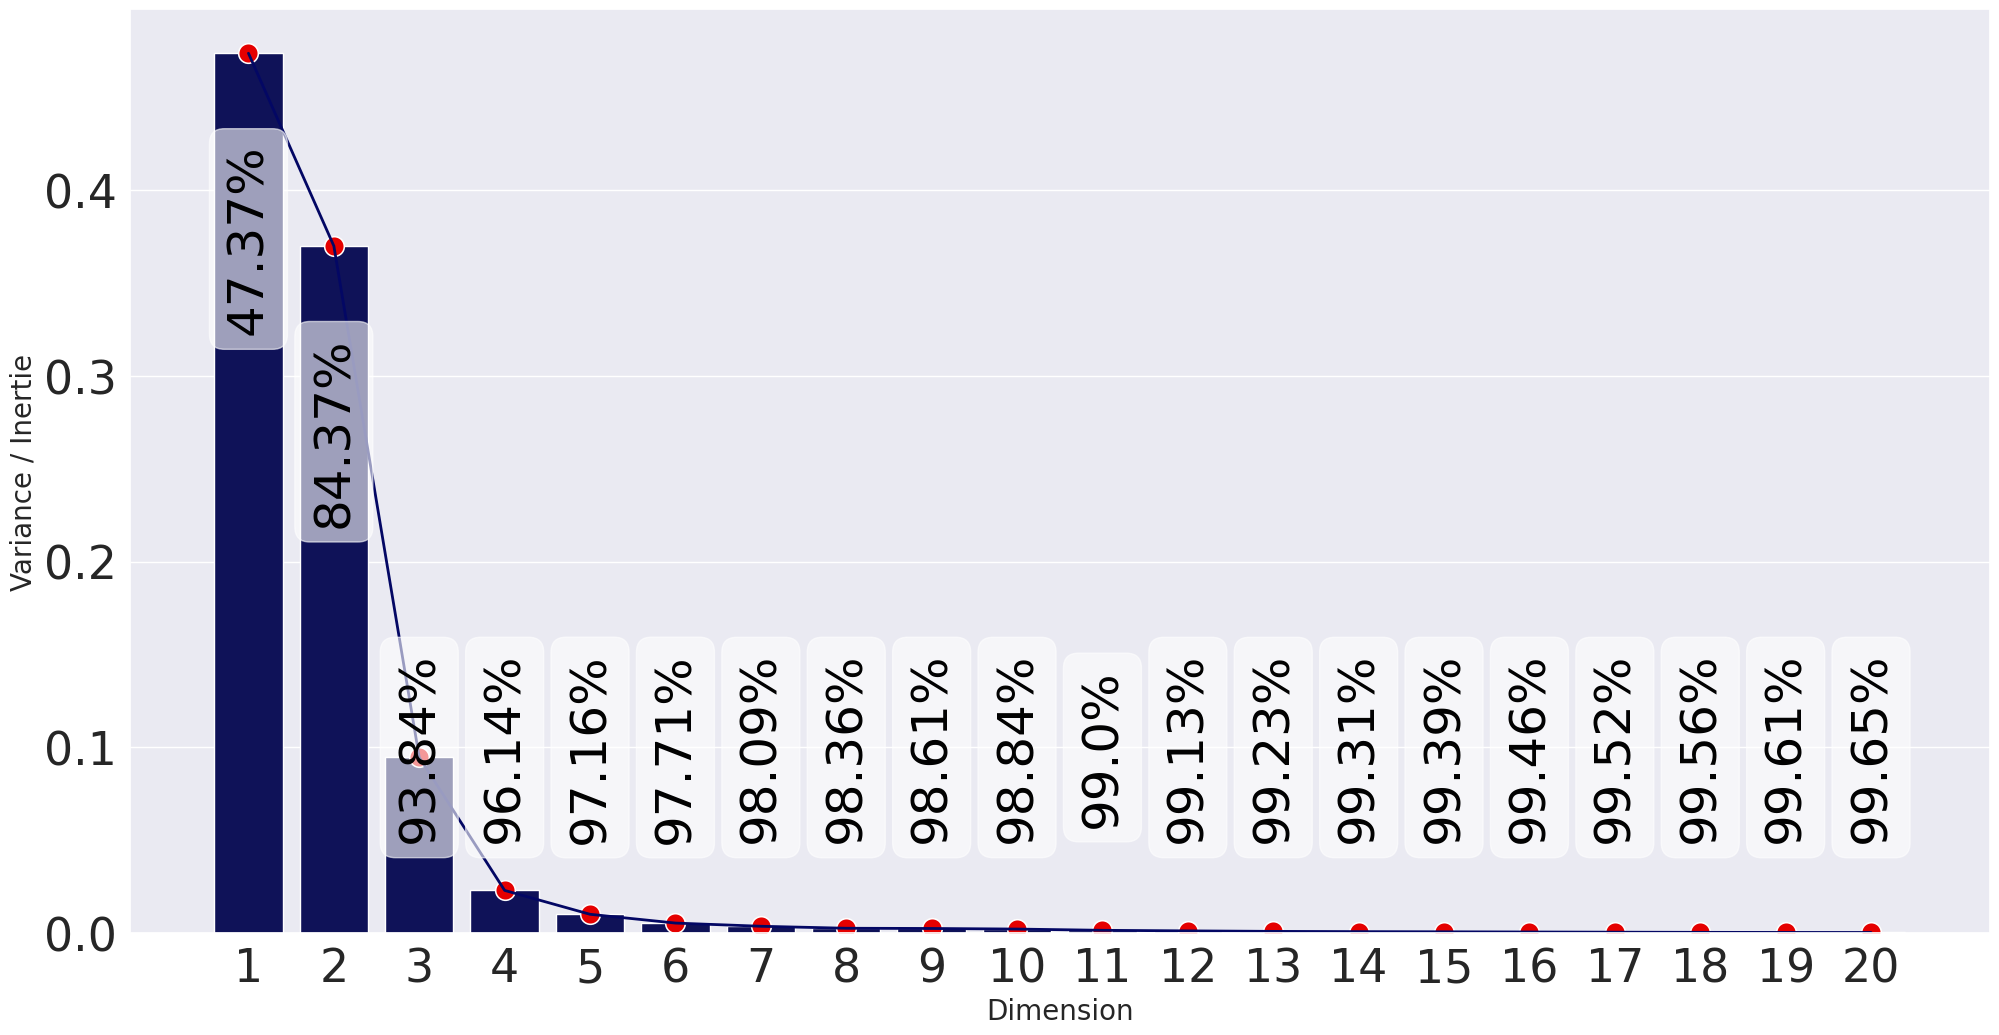

In [11]:
inertie = pd.DataFrame(modelPCA.explained_variance_ratio_,columns=['Inertie']) 
inertie['Label'] = np.round(modelPCA.explained_variance_ratio_.cumsum()*100,2)
inertie['Dimension'] = range(1,len(modelPCA.explained_variance_)+1)
# Affichage des 5 dimensions
dim = 20
inertie = inertie[inertie['Dimension']<= dim]

fig, ax = plt.subplots(figsize=(24,12));
graph = sns.barplot(x="Dimension",y='Inertie', data=inertie, color="#030764", ax=ax)

for i,(nom,valeur) in enumerate(zip(inertie.sort_values('Dimension').Label,inertie.sort_values('Dimension').Inertie)):
    valeur = 0.1 if valeur - 0.1 < 0.1 else valeur - 0.1
    delta =  i 
    graph.text(
                delta ,
                valeur,
                f'{nom}%',
                color='black',
                rotation='vertical',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='center',
               )
    
graph = sns.lineplot( x=inertie.Dimension - 1,
                      y='Inertie',
                      data=inertie,
                      estimator = None, 
                      lw        = 2, 
                      ci        = None,
                      color     = "#030764",
                      ax    = ax);

sns.scatterplot(x=inertie.Dimension - 1,
                y     = 'Inertie',
                data  = inertie,
                s     = 200,
                # ci    = None, 
                color = "#e50000",
                ax    = ax);    
    
plt.xlabel('Dimension', fontproperties=font1)
plt.ylabel('Variance / Inertie', fontproperties=font1)

sauvegarderImage('Choix du nombre des dimensions--Temperatures')
plt.show()
sns.set(font_scale=2)

## Transformation des données 

In [12]:
n_components = sum(modelPCA.explained_variance_ratio_.cumsum() < .95 ) + 1 
modelPCA = PCA(n_components=n_components)
x_proj = modelPCA.fit_transform(donneesJ)
donnees = pd.DataFrame(x_proj, index=donneesJ.index, columns=[f'Dimension{i:02d}' for i in range(1,n_components+1)])

In [13]:
donnees.head()

,,,,,Dimension01,Dimension02,Dimension03,Dimension04
Nom,Latitude,Longitude,Altitude,Zone,,,,
Abbeville,50.136000,1.834000,69,NO,-4.811359,26.130807,-0.523055,-5.601760
Lille,50.570000,3.097500,47,NE,-1.491004,17.572957,-10.179028,-6.424470
Pte De La Hague,49.725167,-1.939833,6,NO,10.543648,29.577911,21.930086,-7.439763
Caen,49.180000,-0.456167,67,NO,-0.871848,26.037489,3.778734,-4.211083
Rouen,49.383000,1.181667,151,NO,-11.439717,21.819682,-3.779959,-1.886567


In [14]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='Zone',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

# Classification hiérarchique ascendante

In [15]:
Villes = donnees.reset_index().Nom.values
donnees.head()

,,,,,Dimension01,Dimension02,Dimension03,Dimension04
Nom,Latitude,Longitude,Altitude,Zone,,,,
Abbeville,50.136000,1.834000,69,NO,-4.811359,26.130807,-0.523055,-5.601760
Lille,50.570000,3.097500,47,NE,-1.491004,17.572957,-10.179028,-6.424470
Pte De La Hague,49.725167,-1.939833,6,NO,10.543648,29.577911,21.930086,-7.439763
Caen,49.180000,-0.456167,67,NO,-0.871848,26.037489,3.778734,-4.211083
Rouen,49.383000,1.181667,151,NO,-11.439717,21.819682,-3.779959,-1.886567


## Calcul des arbres 

In [16]:
def afficheDendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Classification Hiérarchique Ascendante')
        plt.xlabel('Villes ou (taille du cluster)')
        plt.ylabel('Distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata

In [17]:
Z = linkage(donnees, 'ward')

## Affichage des arbres *3 clases* par défaut 

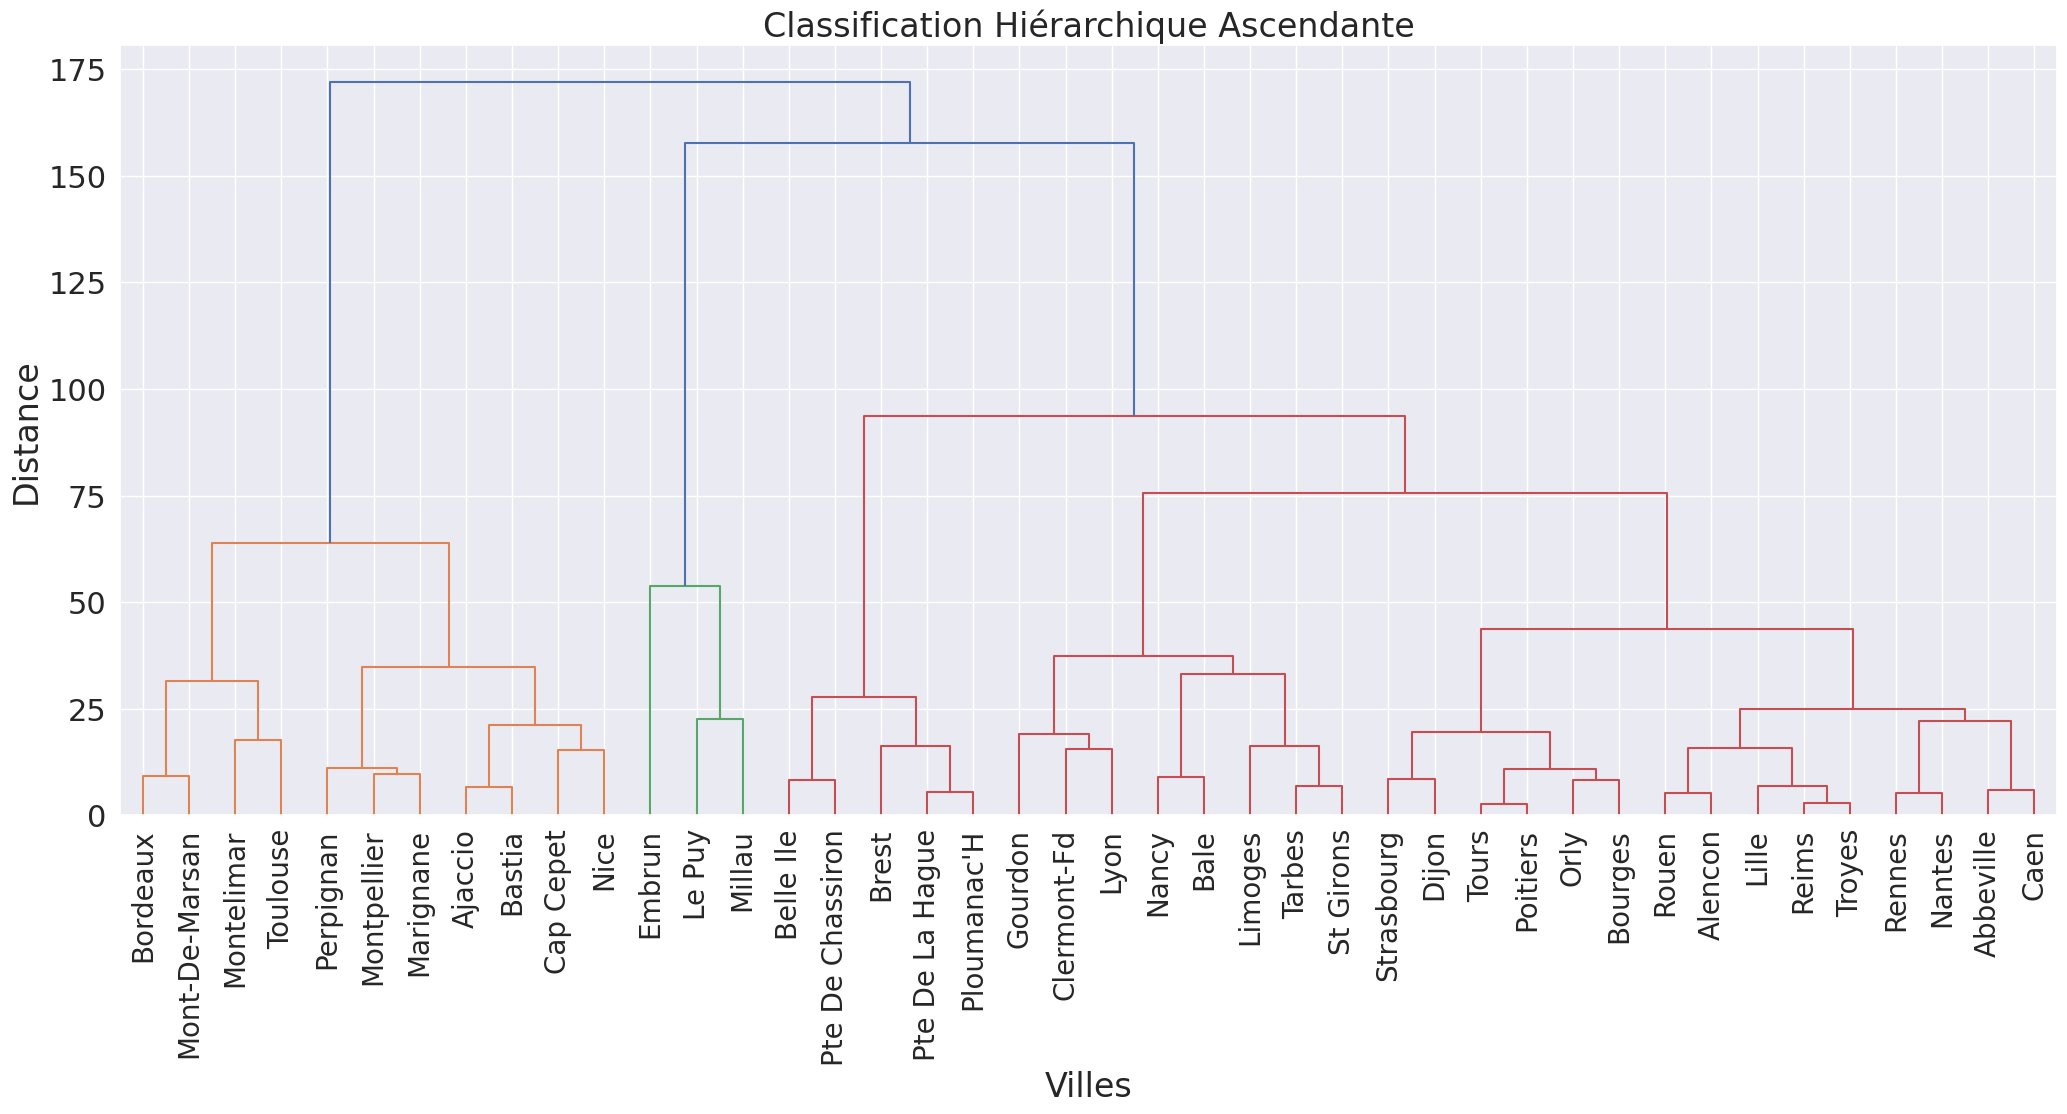

In [18]:
plt.figure(figsize=(25, 10))
plt.title('Classification Hiérarchique Ascendante')
plt.xlabel('Villes')
plt.ylabel('Distance')
dendrogram( Z,leaf_rotation=90.,leaf_font_size=20.,
           labels = Villes)
plt.show()

## Affichage des arbres *6 clases*

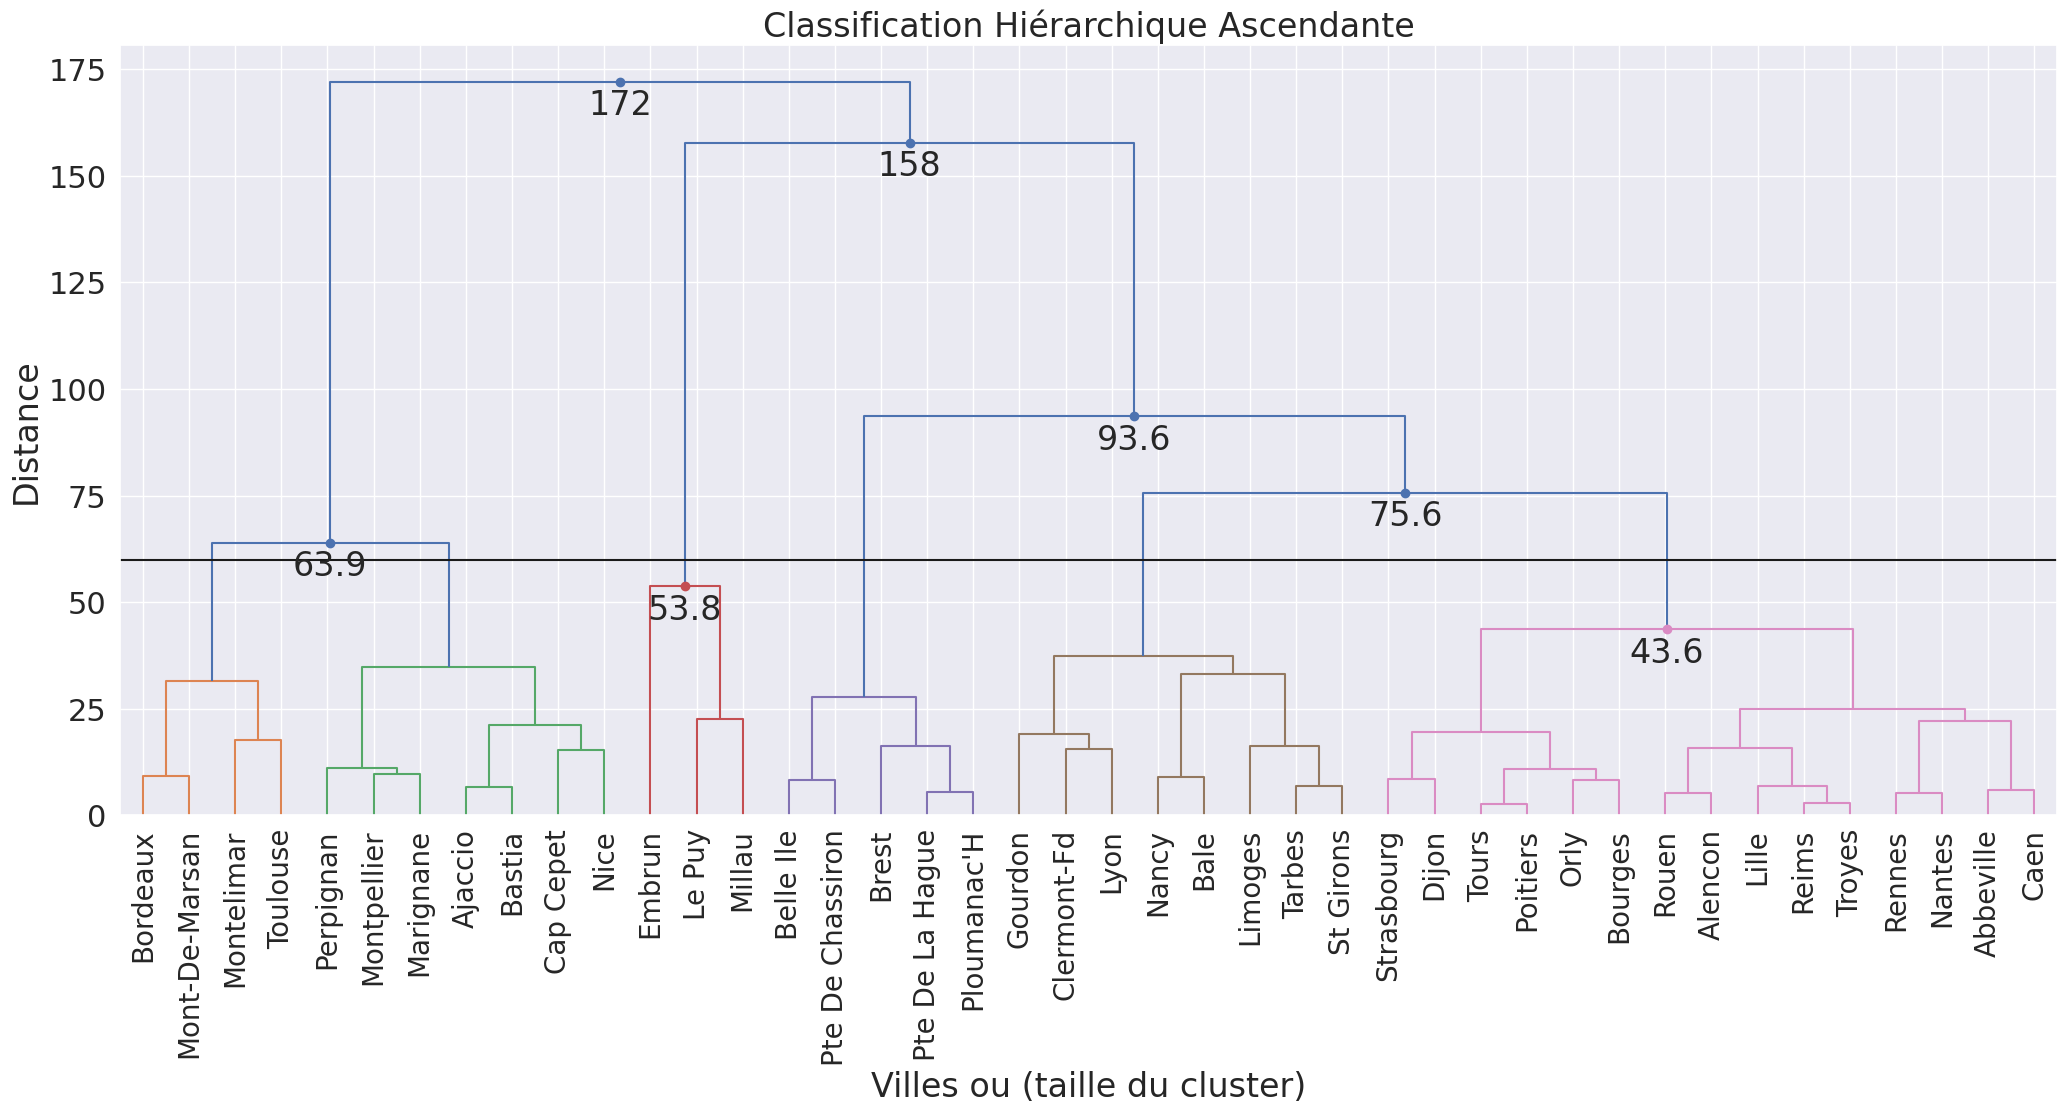

In [19]:
plt.figure(figsize=(25, 10))
afficheDendrogram(
    Z,
    truncate_mode='lastp',
    p=42,                          # nombres des classes
    leaf_rotation=90.,
    leaf_font_size=20.,
    show_contracted=True,
    annotate_above=40,             # les annotations à partir de cette distance
    max_d=60,                      # la distance de découpage de l’arbre
    labels = Villes
)
plt.show()

## Affichage des arbres *5 clases*

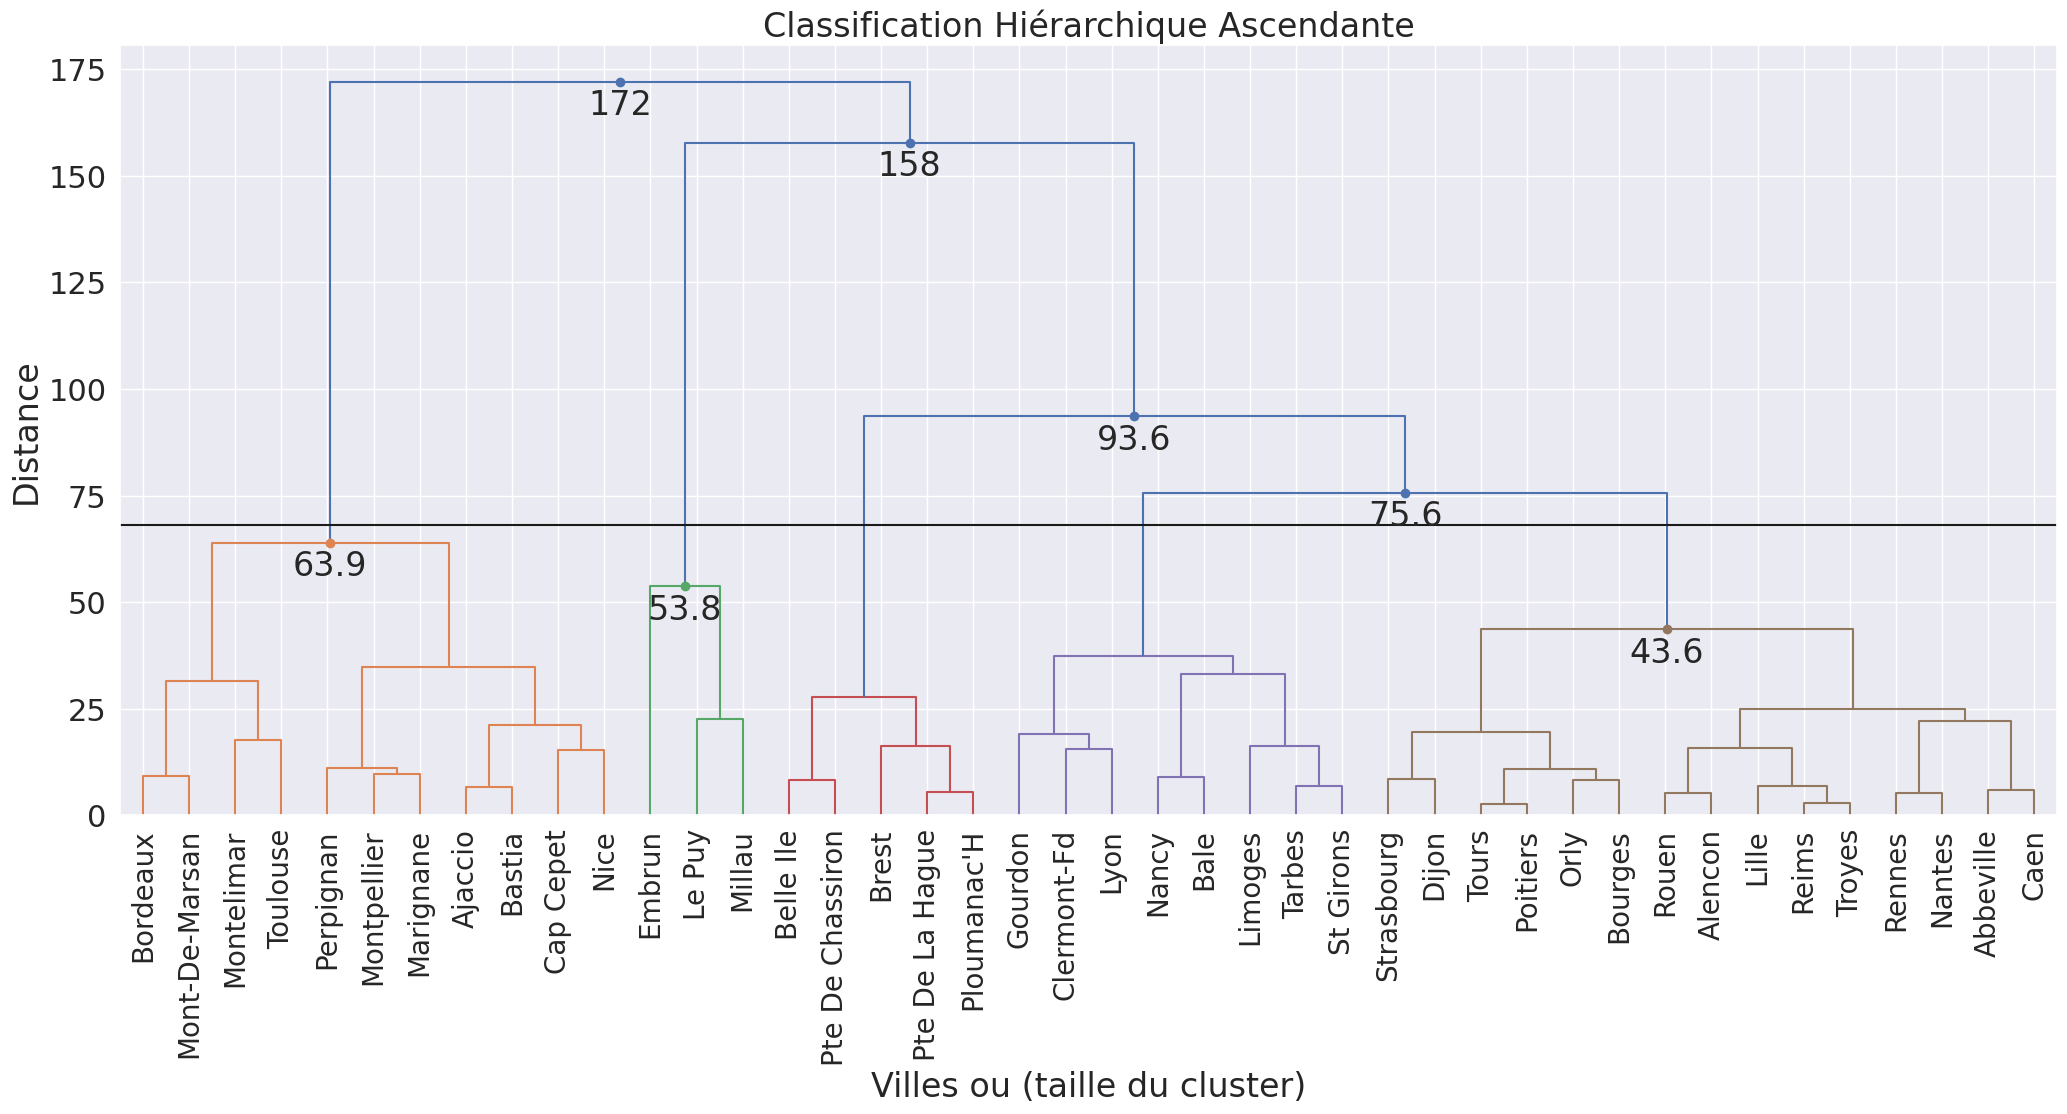

In [20]:
plt.figure(figsize=(25, 10))
afficheDendrogram(
    Z,
    truncate_mode='lastp',
    p=42,                          # nombres des classes
    leaf_rotation=90.,
    leaf_font_size=20.,
    show_contracted=True,
    annotate_above=40,             # les annotations à partir de cette distance
    max_d=68,                      # la distance de découpage de l’arbre
    labels = Villes
)
plt.show()

## Affichage des arbres *4 clases*

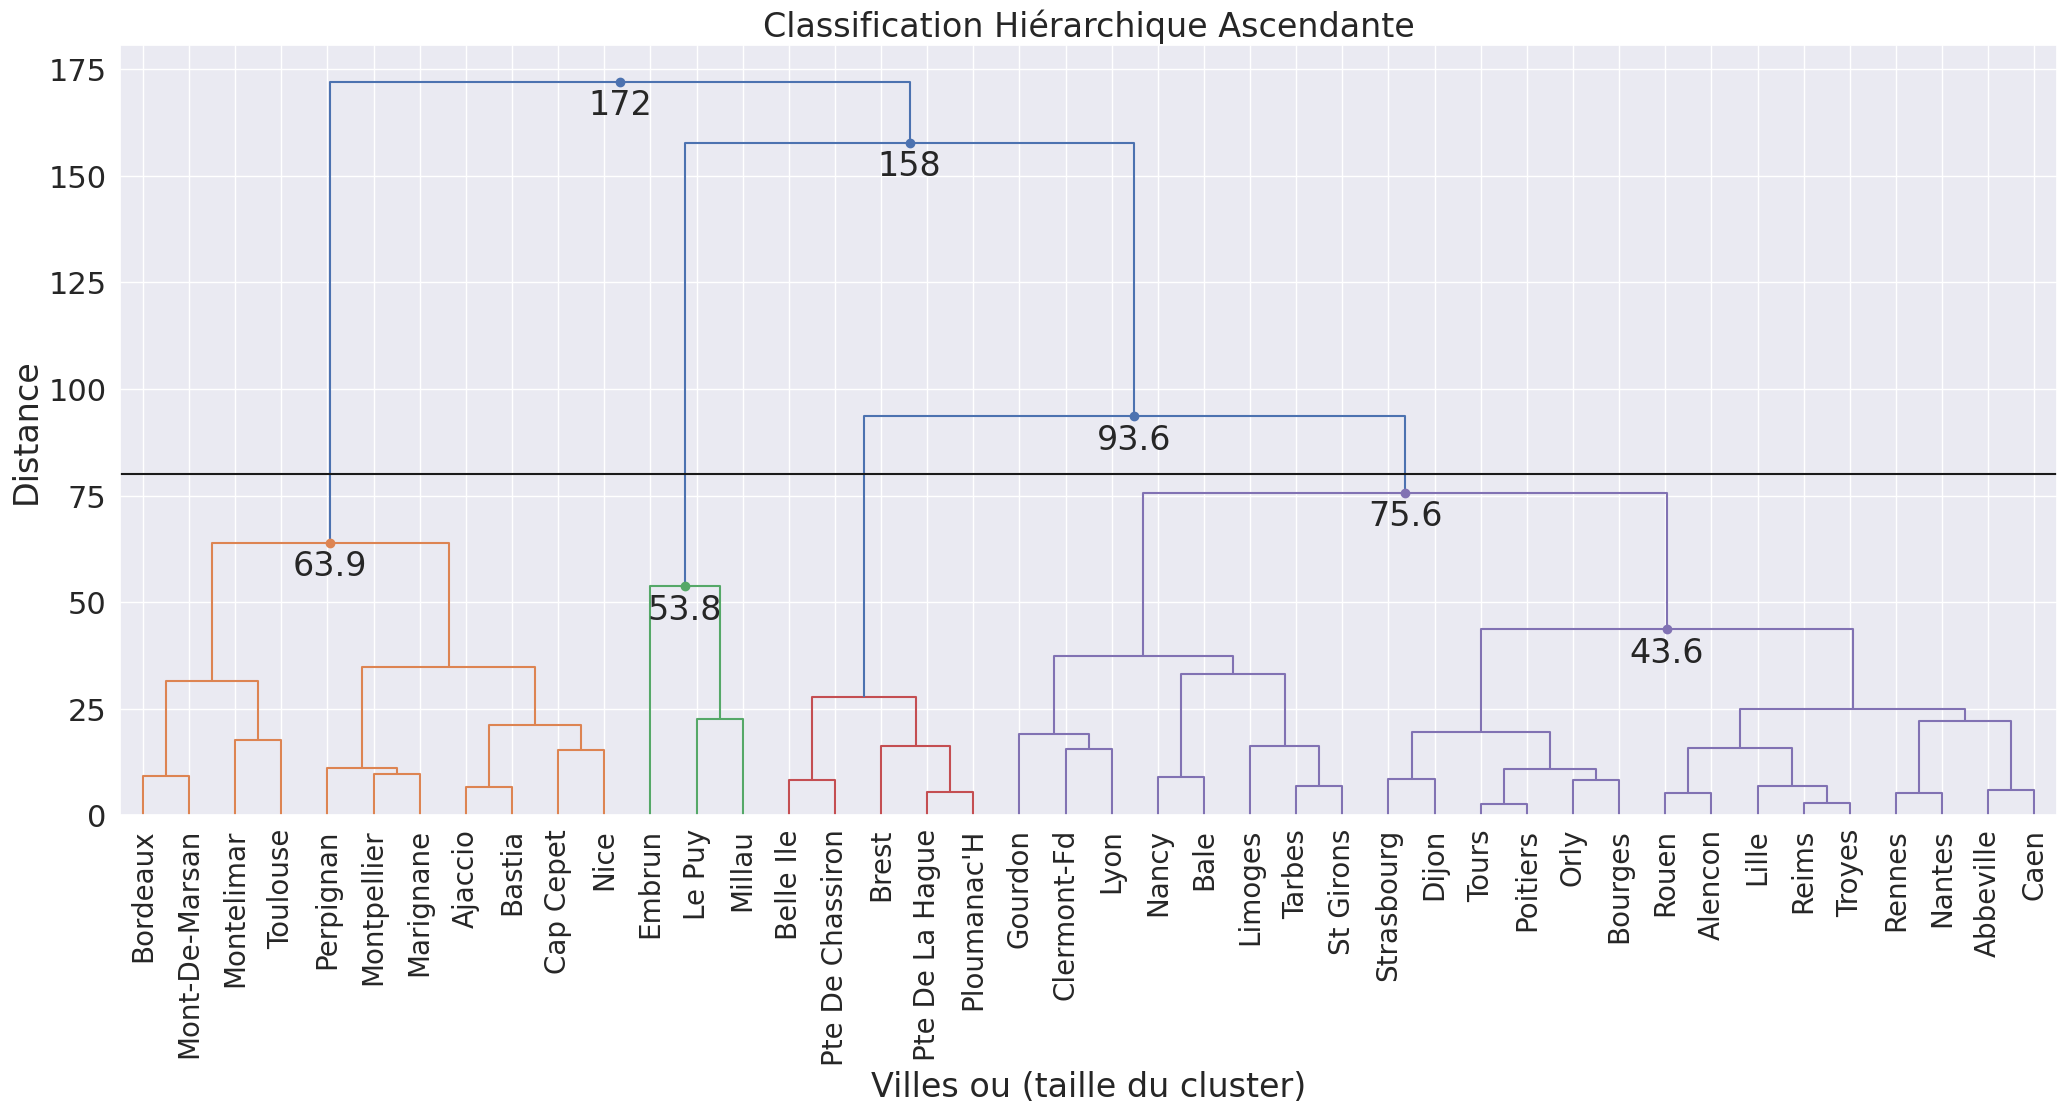

In [21]:
plt.figure(figsize=(25, 10))
afficheDendrogram(
    Z,
    truncate_mode='lastp',
    p=42,                          # nombres des classes
    leaf_rotation=90.,
    leaf_font_size=20.,
    show_contracted=True,
    annotate_above=40,              # les annotations à partir de cette distance
    max_d=80,                      # la distance de découpage de l’arbre
    labels = Villes
)
plt.show()

## Affichage des arbres *3 clases*

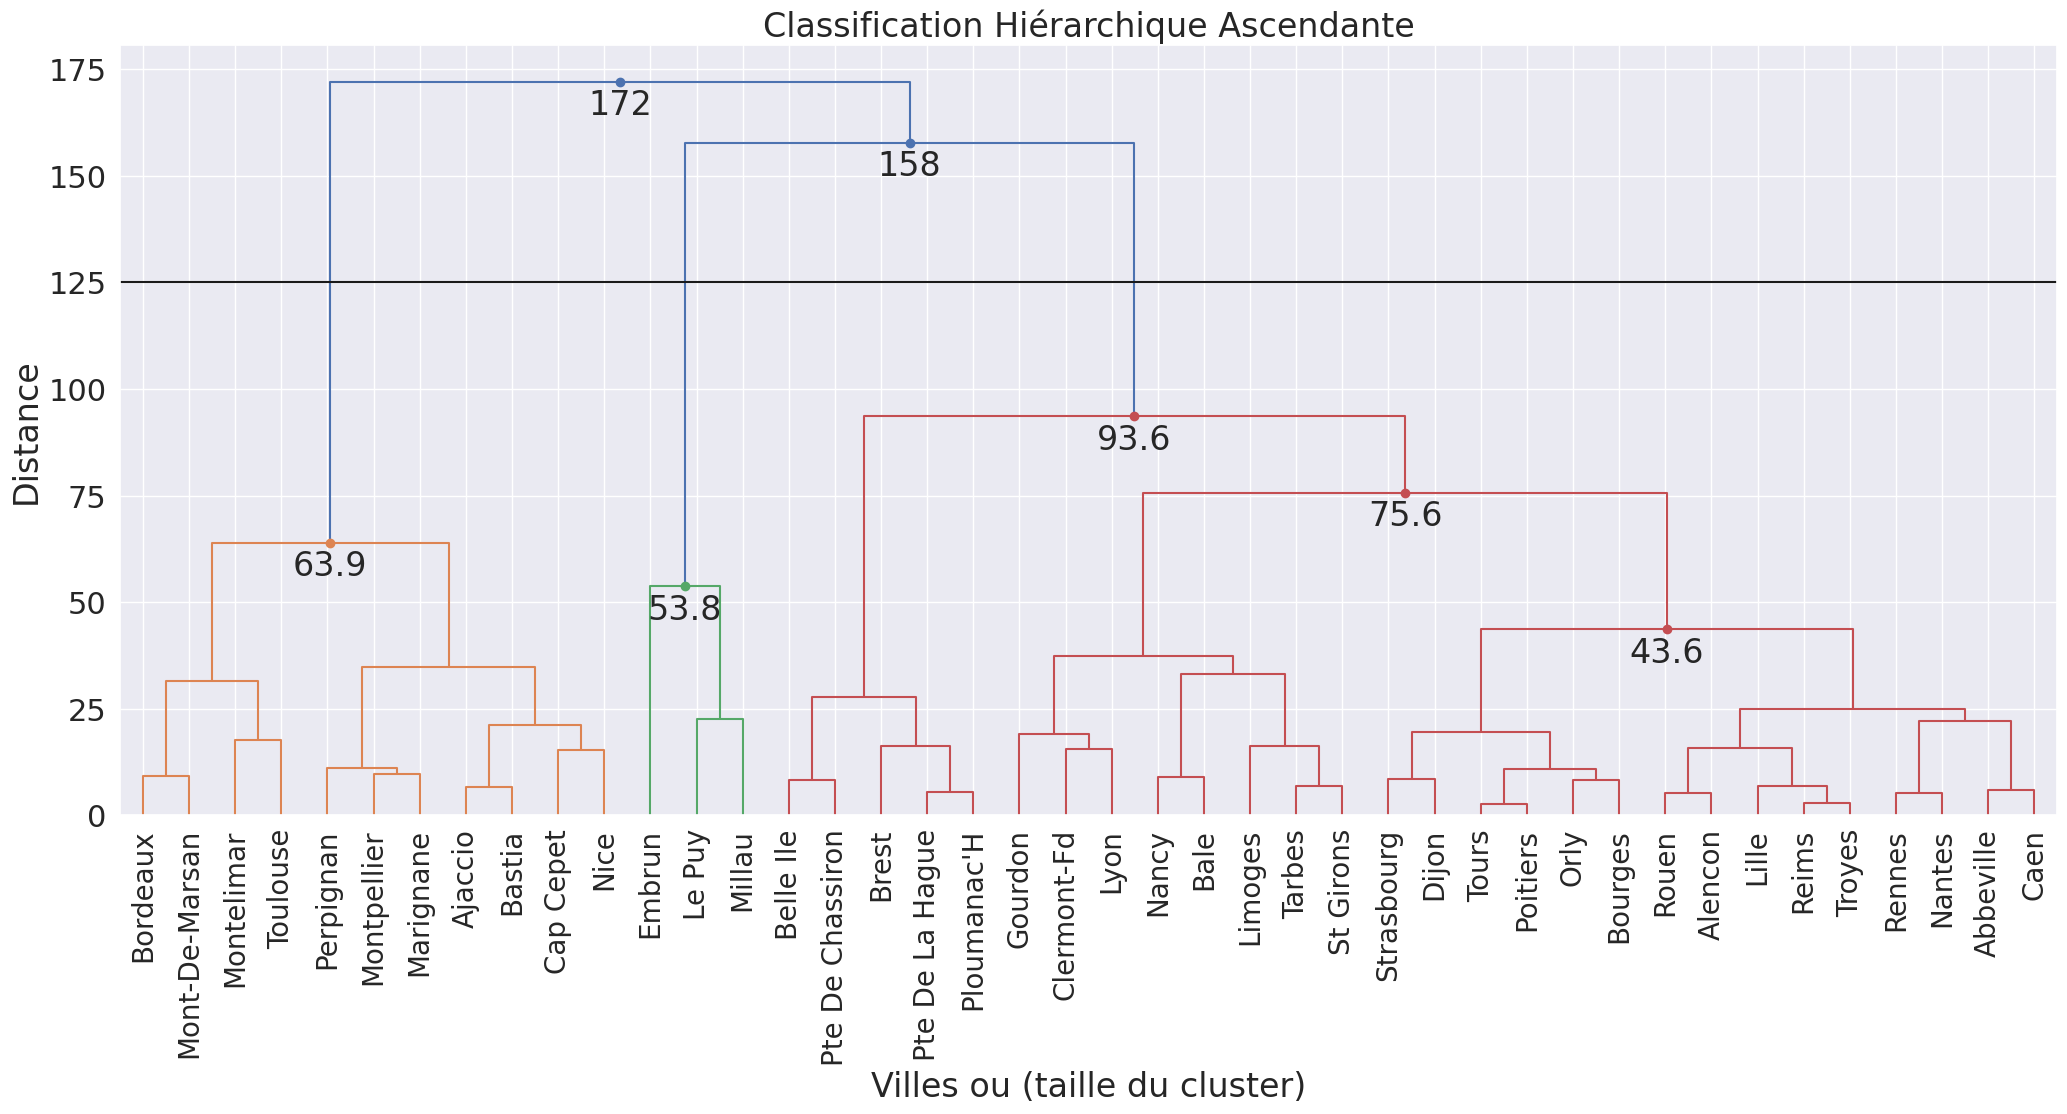

In [22]:
plt.figure(figsize=(25, 10))
afficheDendrogram(
    Z,
    truncate_mode='lastp',
    p=42,                          # nombres des classes
    leaf_rotation=90.,
    leaf_font_size=20.,
    show_contracted=True,
    annotate_above=40,              # les annotations à partir de cette distance
    max_d=125,                      # la distance de découpage de l’arbre
    labels = Villes
)
plt.show()

## Prédiction des classes

In [23]:
donnees['Classes6']=fcluster(Z, t=60, criterion='distance')
donnees['Classes5']=fcluster(Z, t=68, criterion='distance')
donnees['Classes4']=fcluster(Z, t=80, criterion='distance')
donnees['Classes3']=fcluster(Z, t=125, criterion='distance')

In [24]:
donnees.reset_index()

,Nom,Latitude,Longitude,Altitude,Zone,Dimension01,Dimension02,Dimension03,Dimension04,Classes6,Classes5,Classes4,Classes3
0,Abbeville,50.136000,1.834000,69,NO,-4.811359,26.130807,-0.523055,-5.601760,6,5,4,3
1,Lille,50.570000,3.097500,47,NE,-1.491004,17.572957,-10.179028,-6.424470,6,5,4,3
2,Pte De La Hague,49.725167,-1.939833,6,NO,10.543648,29.577911,21.930086,-7.439763,4,3,3,3
3,Caen,49.180000,-0.456167,67,NO,-0.871848,26.037489,3.778734,-4.211083,6,5,4,3
4,Rouen,49.383000,1.181667,151,NO,-11.439717,21.819682,-3.779959,-1.886567,6,5,4,3
5,Reims,49.209667,4.155333,95,NE,-3.620480,14.593219,-9.338238,-3.796088,6,5,4,3
6,Brest,48.444167,-4.412000,94,NO,-1.090187,33.040440,13.518211,-0.653523,4,3,3,3
7,Ploumanac'H,48.825833,-3.473167,55,NO,6.415409,27.903010,19.821145,-5.268968,4,3,3,3
8,Rennes,48.068833,-1.734000,36,NO,6.139510,18.161417,-2.559489,-1.514356,6,5,4,3
9,Alencon,48.445500,0.110167,143,NO,-8.080753,18.077515,-5.015639,-0.629984,6,5,4,3


## Affichage des clusters 

In [25]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='Classes6',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

In [26]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='Classes5',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

In [27]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='Classes4',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

In [28]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='Classes3',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

# Clustering non hiérarchique

In [29]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(donnees.values)
y_kmeans = kmeans.predict(donnees.values)
donnees['KMeans3'] = y_kmeans+1
kmeans = KMeans(n_clusters=4)
kmeans.fit(donnees.values)
y_kmeans = kmeans.predict(donnees.values)
donnees['KMeans4'] = y_kmeans+1
kmeans = KMeans(n_clusters=5)
kmeans.fit(donnees.values)
y_kmeans = kmeans.predict(donnees.values)
donnees['KMeans5'] = y_kmeans+1
kmeans = KMeans(n_clusters=6)
kmeans.fit(donnees.values)
y_kmeans = kmeans.predict(donnees.values)
donnees['KMeans6'] = y_kmeans+1

In [30]:
donnees.head()

,,,,,Dimension01,Dimension02,Dimension03,Dimension04,Classes6,Classes5,Classes4,Classes3,KMeans3,KMeans4,KMeans5,KMeans6
Nom,Latitude,Longitude,Altitude,Zone,,,,,,,,,,,,
Abbeville,50.136000,1.834000,69,NO,-4.811359,26.130807,-0.523055,-5.601760,6,5,4,3,1,2,4,3
Lille,50.570000,3.097500,47,NE,-1.491004,17.572957,-10.179028,-6.424470,6,5,4,3,2,2,2,3
Pte De La Hague,49.725167,-1.939833,6,NO,10.543648,29.577911,21.930086,-7.439763,4,3,3,3,1,2,4,5
Caen,49.180000,-0.456167,67,NO,-0.871848,26.037489,3.778734,-4.211083,6,5,4,3,1,2,4,3
Rouen,49.383000,1.181667,151,NO,-11.439717,21.819682,-3.779959,-1.886567,6,5,4,3,2,2,2,3


In [31]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='KMeans6',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

In [32]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='KMeans5',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

In [33]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='KMeans4',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()

In [34]:
layout = go.Layout({"showlegend": False})
affichage = donnees.reset_index()
fig = px.scatter_3d(affichage, 
                    x='Dimension01', 
                    y='Dimension02', 
                    z='Dimension03',
                    color='KMeans3',
                    # size= 'Dimension04',
                    # symbol=donnees.CD23.cat.codes,
                    text='Nom',
                    width=1024,
                    height=1024,
                   )

fig.show()